<a href="https://colab.research.google.com/github/Divya4325/Global-Literacy-Education-Trends/blob/main/Global_Literacy_%26_Education_Trends_An_Analytical_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Collection**


Adult literacy *Rate*

In [ ]:
import pandas as pd
df_adult_literacy=pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-adults.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_adult_literacy.head()

,entity,code,year,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99
0,Afghanistan,AFG,1979,18.00000
1,Afghanistan,AFG,2011,31.00000
2,Afghanistan,AFG,2015,33.75384
3,Afghanistan,AFG,2021,37.00000
4,Albania,ALB,2001,99.00000


In [ ]:
df_adult_literacy.to_csv("Adult_literacy_rate.csv")


*Youth Literacy Rate (Male, Female)*

In [ ]:
df_youth_literacy=pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-of-young-men-and-women.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_youth_literacy.head()

,entity,code,year,youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m,youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f,owid_region
0,Afghanistan,AFG,1979,46.00000,11.00000,Asia
1,Afghanistan,AFG,2011,62.00000,32.00000,Asia
2,Afghanistan,AFG,2015,57.73505,25.48416,Asia
3,Afghanistan,AFG,2021,71.00000,42.00000,Asia
4,Afghanistan,AFG,2022,83.40000,44.17171,Asia


In [ ]:
df_youth_literacy.to_csv("Youth_literacy_rate.csv")


Illiterate Population (Total, Male, Female)

In [ ]:
df_illiteracy=pd.read_csv("https://ourworldindata.org/grapher/literate-and-illiterate-world-population.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_illiteracy.head()

,entity,code,year,illiteracy_rate,literacy_rate
0,Afghanistan,AFG,1950,97.000000,3.00000
1,Afghanistan,AFG,1979,82.000000,18.00000
2,Afghanistan,AFG,2011,69.000000,31.00000
3,Afghanistan,AFG,2015,66.246155,33.75384
4,Afghanistan,AFG,2021,63.000000,37.00000


In [ ]:
df_illiteracy.to_csv("Illiterate_population_csv")


*GDP per Capita*

In [ ]:
df_gdp=pd.read_csv("https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_gdp.head()

,entity,code,year,ny_gdp_pcap_pp_kd,owid_region
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia


In [ ]:
df_gdp.to_csv("GDP_per_capita.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

*Average Years of Schooling*

In [ ]:
df_schooling=pd.read_csv("https://ourworldindata.org/grapher/literacy-rates-vs-average-years-of-schooling.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_schooling.head()

,entity,code,year,literacy_rate,mf_youth_and_adults__15_64_years__average_years_of_education,population_historical,owid_region
0,Afghanistan,AFG,1870,NaN,0.01,4101170.0,Asia
1,Afghanistan,AFG,1875,NaN,0.01,4193635.0,Asia
2,Afghanistan,AFG,1880,NaN,0.01,4288021.0,Asia
3,Afghanistan,AFG,1885,NaN,0.01,4384343.0,Asia
4,Afghanistan,AFG,1890,NaN,0.01,4482635.0,Asia


In [ ]:
df_gdp.to_csv("Average_schooling_csv")

# **Data Understanding**

*Checking column names and merging columns*

In [ ]:
df_adult_literacy.columns

Index(['entity', 'code', 'year',
       'adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99'],
      dtype='object')

In [ ]:
df_adult_literacy.rename(columns={"adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99":"Total_literacy_population",
                                  "entity":"country","code":"country_code"
                                  },inplace=True)

In [ ]:
df_youth_literacy.columns

Index(['entity', 'code', 'year',
       'youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m',
       'youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f',
       'owid_region'],
      dtype='object')

In [ ]:
df_youth_literacy.rename(columns={"youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m":"male_literacy",
                                  "youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f":"female_literacy",
                                  "entity":"country","owid_region":"continent","code":"country_code"
                                  },inplace=True)

**df_literacy[Merging columns]**

In [ ]:
df_literacy=df_adult_literacy.merge(df_youth_literacy,on=["country","country_code","year"],how='inner')

In [ ]:
df_literacy.columns

Index(['country', 'country_code', 'year', 'Total_literacy_population',
       'male_literacy', 'female_literacy', 'continent'],
      dtype='object')

In [ ]:
df_literacy=df_literacy.reset_index(drop=True)

In [ ]:
df_literacy

,country,country_code,year,Total_literacy_population,male_literacy,female_literacy,continent
0,Afghanistan,AFG,1979,18.00000,46.00000,11.00000,Asia
1,Afghanistan,AFG,2011,31.00000,62.00000,32.00000,Asia
2,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia
3,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia
4,Albania,ALB,2001,99.00000,99.00000,99.00000,Europe
...,...,...,...,...,...,...,...
1703,Zambia,ZMB,2010,83.00000,91.00000,87.00000,Africa
1704,Zambia,ZMB,2018,71.13230,82.44786,72.90992,Africa
1705,Zimbabwe,ZWE,1982,78.00000,94.00000,85.00000,Africa
1706,Zimbabwe,ZWE,1992,84.00000,97.00000,94.00000,Africa


**df_illiteracy**

In [ ]:
df_illiteracy.rename(columns={"entity":"country","code":"country_code"},inplace=True)

In [ ]:
df_illiteracy

,country,country_code,year,illiteracy_rate,literacy_rate
0,Afghanistan,AFG,1950,97.000000,3.00000
1,Afghanistan,AFG,1979,82.000000,18.00000
2,Afghanistan,AFG,2011,69.000000,31.00000
3,Afghanistan,AFG,2015,66.246155,33.75384
4,Afghanistan,AFG,2021,63.000000,37.00000
...,...,...,...,...,...
2054,Zanzibar,OWID_ZAN,1950,92.500000,7.50000
2055,Zimbabwe,ZWE,1950,77.500000,22.50000
2056,Zimbabwe,ZWE,1982,22.000000,78.00000
2057,Zimbabwe,ZWE,1992,16.000000,84.00000


In [ ]:
df_gdp.columns

Index(['entity', 'code', 'year', 'ny_gdp_pcap_pp_kd', 'owid_region'], dtype='object')

In [ ]:
df_gdp.rename(columns={
    "entity": "country",
    "code": "country_code",
    "ny_gdp_pcap_pp_kd": "gdp_per_capita",
    "owid_region": "continent"
},inplace=True)

In [ ]:
df_schooling.columns

Index(['entity', 'code', 'year', 'literacy_rate',
       'mf_youth_and_adults__15_64_years__average_years_of_education',
       'population_historical', 'owid_region'],
      dtype='object')

In [ ]:
df_schooling.rename(columns={"entity":"country",
           "code":"country_code",
           "mf_youth_and_adults__15_64_years__average_years_of_education":"avg_years_schooling",
           "owid_region":"continent"},inplace=True)

**df_gdp_schooling**

In [ ]:
df_gdp_schooling=df_gdp.merge(df_schooling,on=["country","country_code","continent"],how='inner')

In [ ]:
df_gdp_schooling

,country,country_code,year_x,gdp_per_capita,continent,year_y,literacy_rate,avg_years_schooling,population_historical
0,Afghanistan,AFG,2000,1617.8264,Asia,1870,NaN,0.01,4101170.0
1,Afghanistan,AFG,2000,1617.8264,Asia,1875,NaN,0.01,4193635.0
2,Afghanistan,AFG,2000,1617.8264,Asia,1880,NaN,0.01,4288021.0
3,Afghanistan,AFG,2000,1617.8264,Asia,1885,NaN,0.01,4384343.0
4,Afghanistan,AFG,2000,1617.8264,Asia,1890,NaN,0.01,4482635.0
...,...,...,...,...,...,...,...,...,...
148189,Zimbabwe,ZWE,2024,5215.2530,Africa,2005,NaN,7.65,12483433.0
148190,Zimbabwe,ZWE,2024,5215.2530,Africa,2010,NaN,7.86,13356551.0
148191,Zimbabwe,ZWE,2024,5215.2530,Africa,2015,NaN,8.03,14399008.0
148192,Zimbabwe,ZWE,2024,5215.2530,Africa,2019,93.22755,NaN,15271377.0


# Data Cleaning

*1) Handling Missing values:*

`df_literacy`

In [ ]:
df_literacy.isnull().sum()  # So here totally 729 null values in country_code and 777 null values in continent

,0
country,0
country_code,729
year,0
Total_literacy_population,0
male_literacy,0
female_literacy,0
continent,777


In [ ]:
df_literacy=df_literacy.dropna() # So here I drop the null values

In [ ]:
df_literacy

,country,country_code,year,Total_literacy_population,male_literacy,female_literacy,continent
0,Afghanistan,AFG,1979,18.00000,46.00000,11.00000,Asia
1,Afghanistan,AFG,2011,31.00000,62.00000,32.00000,Asia
2,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia
3,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia
4,Albania,ALB,2001,99.00000,99.00000,99.00000,Europe
...,...,...,...,...,...,...,...
1703,Zambia,ZMB,2010,83.00000,91.00000,87.00000,Africa
1704,Zambia,ZMB,2018,71.13230,82.44786,72.90992,Africa
1705,Zimbabwe,ZWE,1982,78.00000,94.00000,85.00000,Africa
1706,Zimbabwe,ZWE,1992,84.00000,97.00000,94.00000,Africa


In [ ]:
df_literacy.isnull().sum() # So there is no null value in df_literacy

,0
country,0
country_code,0
year,0
Total_literacy_population,0
male_literacy,0
female_literacy,0
continent,0


`*df_illiteracy*`

In [ ]:
df_illiteracy.isnull().sum()  # So here totally 733 null values in country_code

,0
country,0
country_code,733
year,0
illiteracy_rate,0
literacy_rate,0


In [ ]:
df_illiteracy=df_illiteracy.dropna() # So here I drop the null values

In [ ]:
df_illiteracy

,country,country_code,year,illiteracy_rate,literacy_rate
0,Afghanistan,AFG,1950,97.000000,3.00000
1,Afghanistan,AFG,1979,82.000000,18.00000
2,Afghanistan,AFG,2011,69.000000,31.00000
3,Afghanistan,AFG,2015,66.246155,33.75384
4,Afghanistan,AFG,2021,63.000000,37.00000
...,...,...,...,...,...
2054,Zanzibar,OWID_ZAN,1950,92.500000,7.50000
2055,Zimbabwe,ZWE,1950,77.500000,22.50000
2056,Zimbabwe,ZWE,1982,22.000000,78.00000
2057,Zimbabwe,ZWE,1992,16.000000,84.00000


`df_gdp_schooling`

In [ ]:
df_gdp_schooling.isnull().sum() # So here are 106529 null values in literacy rate and 31294 avg years schooling in avg_years_schooling

,0
country,0
country_code,0
year_x,0
gdp_per_capita,0
continent,0
year_y,0
literacy_rate,106529
avg_years_schooling,31294
population_historical,0


In [ ]:
df_gdp_schooling=df_gdp_schooling.fillna(df_gdp_schooling.mean(numeric_only=True))

In [ ]:
df_gdp_schooling.isnull().sum()  # So there is no null value in df_gdp_schooling

,0
country,0
country_code,0
year_x,0
gdp_per_capita,0
continent,0
year_y,0
literacy_rate,0
avg_years_schooling,0
population_historical,0


**2).Remove Duplicates**

In [ ]:
df_literacy.duplicated().sum() # Here no duplicates found

np.int64(0)

In [ ]:
df_illiteracy.duplicated().sum() # Here no duplicates found

np.int64(4)

In [ ]:
df_gdp_schooling.duplicated().sum() # Here no duplicates found

np.int64(0)

**3)Standardize country names for merging**

In [ ]:
df_literacy["country"].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Angola',
       'Anguilla', 'Argentina', 'Armenia', 'Aruba', 'Azerbaijan',
       'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belize', 'Benin',
       'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana',
       'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi',
       'Cambodia', 'Cameroon', 'Cape Verde', 'Cayman Islands',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo', 'Costa Rica', "Cote d'Ivoire", 'Croatia',
       'Cuba', 'Cyprus', 'Democratic Republic of Congo',
       'Dominican Republic', 'East Timor', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Georgia', 'Ghana',
       'Greece', 'Grenada', 'Guadeloupe', 'Guam', 'Guatemala', 'Guinea',
       'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'Hungary', 'India',
       'Indonesia', 'Iran', 'Iraq', 'Israel', 'I

In [ ]:
df_literacy['country'] = df_literacy['country'].str.lower().str.strip()

/tmp/ipykernel_1611/2954850591.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_literacy['country'] = df_literacy['country'].str.lower().str.strip()


In [ ]:
df_literacy["country"].unique()

array(['afghanistan', 'albania', 'algeria', 'american samoa', 'angola',
       'anguilla', 'argentina', 'armenia', 'aruba', 'azerbaijan',
       'bahrain', 'bangladesh', 'barbados', 'belarus', 'belize', 'benin',
       'bhutan', 'bolivia', 'bosnia and herzegovina', 'botswana',
       'brazil', 'brunei', 'bulgaria', 'burkina faso', 'burundi',
       'cambodia', 'cameroon', 'cape verde', 'cayman islands',
       'central african republic', 'chad', 'chile', 'china', 'colombia',
       'comoros', 'congo', 'costa rica', "cote d'ivoire", 'croatia',
       'cuba', 'cyprus', 'democratic republic of congo',
       'dominican republic', 'east timor', 'ecuador', 'egypt',
       'el salvador', 'equatorial guinea', 'eritrea', 'estonia',
       'eswatini', 'ethiopia', 'gabon', 'gambia', 'georgia', 'ghana',
       'greece', 'grenada', 'guadeloupe', 'guam', 'guatemala', 'guinea',
       'guinea-bissau', 'guyana', 'haiti', 'honduras', 'hungary', 'india',
       'indonesia', 'iran', 'iraq', 'israel', 'i

In [ ]:
df_illiteracy["country"].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina',
       'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan',
       'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus',
       'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei',
       'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
       'Canada', 'Cape Verde', 'Cayman Islands',
       'Central African Republic', 'Central and Southern Asia (SDG)',
       'Chad', 'Channel Islands', 'Chile', 'China', 'Cocos Islands',
       'Colombia', 'Comoros', 'Congo', 'Cook Islands', 'Costa Rica',
       "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czechoslovakia',
       'Democratic Republic of Congo', 'Denmark', 'Djibouti',
       'Dominican Republic', 'East Asia and Pacific (WB)', 'East Timor',
       'Eastern and South-Eastern Asia (SDG)', 'Ecuador', 'Egypt

In [ ]:
df_illiteracy["country"]=df_illiteracy["country"].str.lower().str.strip()

In [ ]:
df_illiteracy["country"].unique()

array(['afghanistan', 'albania', 'algeria', 'american samoa', 'andorra',
       'angola', 'anguilla', 'antigua and barbuda', 'argentina',
       'armenia', 'aruba', 'australia', 'austria', 'azerbaijan',
       'bahamas', 'bahrain', 'bangladesh', 'barbados', 'belarus',
       'belgium', 'belize', 'benin', 'bermuda', 'bhutan', 'bolivia',
       'bosnia and herzegovina', 'botswana', 'brazil', 'brunei',
       'bulgaria', 'burkina faso', 'burundi', 'cambodia', 'cameroon',
       'canada', 'cape verde', 'cayman islands',
       'central african republic', 'central and southern asia (sdg)',
       'chad', 'channel islands', 'chile', 'china', 'cocos islands',
       'colombia', 'comoros', 'congo', 'cook islands', 'costa rica',
       "cote d'ivoire", 'croatia', 'cuba', 'cyprus', 'czechoslovakia',
       'democratic republic of congo', 'denmark', 'djibouti',
       'dominican republic', 'east asia and pacific (wb)', 'east timor',
       'eastern and south-eastern asia (sdg)', 'ecuador', 'egypt

In [ ]:
df_gdp_schooling["country"].unique() # don't run this again

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Cayman Islands', 'Central African Republic', 'Chad', 'Chile',
       'China', 'Colombia', 'Comoros', 'Congo', 'Costa Rica',
       "Cote d'Ivoire", 'Croatia', 'Cyprus', 'Czechia',
       'Democratic Republic of Congo', 'Denmark', 'Djibouti',
       'Dominican Republic', 'East Timor', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Estonia', 'Eswatini',
       'Ethiopia', 'Faroe Islands', 'Fiji', 'Finland', 'France', 'Gabon',
       'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Greenland',
       'G

In [ ]:
df_gdp_schooling["country"]=df_gdp_schooling["country"].str.lower().str.strip()

In [ ]:
df_gdp_schooling["country"].unique()

array(['afghanistan', 'albania', 'algeria', 'andorra', 'angola',
       'antigua and barbuda', 'argentina', 'armenia', 'aruba',
       'australia', 'austria', 'azerbaijan', 'bahamas', 'bahrain',
       'bangladesh', 'barbados', 'belarus', 'belgium', 'belize', 'benin',
       'bermuda', 'bhutan', 'bolivia', 'bosnia and herzegovina',
       'botswana', 'brazil', 'brunei', 'bulgaria', 'burkina faso',
       'burundi', 'cambodia', 'cameroon', 'canada', 'cape verde',
       'cayman islands', 'central african republic', 'chad', 'chile',
       'china', 'colombia', 'comoros', 'congo', 'costa rica',
       "cote d'ivoire", 'croatia', 'cyprus', 'czechia',
       'democratic republic of congo', 'denmark', 'djibouti',
       'dominican republic', 'east timor', 'ecuador', 'egypt',
       'el salvador', 'equatorial guinea', 'estonia', 'eswatini',
       'ethiopia', 'faroe islands', 'fiji', 'finland', 'france', 'gabon',
       'gambia', 'georgia', 'germany', 'ghana', 'greece', 'greenland',
       'g

**4).Understand the shape and structure of the data**

In [ ]:
df_literacy.shape

(931, 7)

In [ ]:
df_literacy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 931 entries, 0 to 1707
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country                    931 non-null    object 
 1   country_code               931 non-null    object 
 2   year                       931 non-null    int64  
 3   Total_literacy_population  931 non-null    float64
 4   male_literacy              931 non-null    float64
 5   female_literacy            931 non-null    float64
 6   continent                  931 non-null    object 
dtypes: float64(3), int64(1), object(3)
memory usage: 58.2+ KB


In [ ]:
df_illiteracy.shape

(2059, 5)

In [ ]:
df_illiteracy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          2059 non-null   object 
 1   country_code     1326 non-null   object 
 2   year             2059 non-null   int64  
 3   illiteracy_rate  2059 non-null   float64
 4   literacy_rate    2059 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 80.6+ KB


In [ ]:
df_gdp_schooling.shape

(148194, 9)

In [ ]:
df_gdp_schooling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148194 entries, 0 to 148193
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   country                148194 non-null  object 
 1   country_code           148194 non-null  object 
 2   year_x                 148194 non-null  int64  
 3   gdp_per_capita         148194 non-null  float64
 4   continent              148194 non-null  object 
 5   year_y                 148194 non-null  int64  
 6   literacy_rate          148194 non-null  float64
 7   avg_years_schooling    148194 non-null  float64
 8   population_historical  148194 non-null  float64
dtypes: float64(4), int64(2), object(3)
memory usage: 10.2+ MB


**5).Identify any unusual values**

In [ ]:
df_literacy.describe()  #There is no unusual values Need to check once once Chatgpt works

,year,Total_literacy_population,male_literacy,female_literacy
count,931.000000,931.000000,931.000000,931.000000
mean,2006.386681,80.751500,90.815001,87.064544
std,12.240546,20.928725,13.939630,20.359928
min,1970.000000,9.000000,22.000000,7.000000
25%,2000.000000,70.000000,88.000000,82.161700
50%,2010.000000,90.000000,97.600000,98.000000
75%,2016.000000,96.000000,99.000000,99.000000
max,2023.000000,100.000000,100.000000,100.000000


In [ ]:
df_illiteracy.describe() #There is no unusual values Need to check once once Chatgpt works

,year,illiteracy_rate,literacy_rate
count,2059.000000,2059.000000,2059.000000
mean,1986.084507,27.421922,72.578078
std,64.008447,24.485748,24.485748
min,1475.000000,0.000000,0.000000
25%,1983.000000,6.704529,57.981690
50%,2002.000000,21.000000,79.000000
75%,2013.000000,42.018310,93.295470
max,2023.000000,100.000000,100.000000


In [ ]:
df_gdp_schooling.describe()

,year,gdp_per_capita,literacy_rate,avg_years_schooling,population_historical
count,148194.000000,148194.000000,41665.000000,116900.000000,1.481940e+05
mean,2007.047917,21588.545143,72.515748,3.831224,3.006120e+07
std,10.072201,22929.699459,27.971388,3.657918,1.058168e+08
min,1990.000000,510.822800,0.000000,0.010000,3.424000e+03
25%,1998.000000,4825.406200,55.000000,0.540000,1.883502e+06
50%,2007.000000,12512.184000,85.000000,2.780000,5.868459e+06
75%,2016.000000,32925.664000,95.000000,6.400000,1.808418e+07
max,2024.000000,174569.520000,100.000000,13.740000,1.438070e+09


**6)Rename column names for clarity**

In [ ]:
df_gdp_schooling["year_x"].unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998,
       1999, 2024])

In [ ]:
df_gdp_schooling["year_y"].unique()

KeyError: 'year_y'

In [ ]:
df_gdp_schooling=df_gdp_schooling.drop(columns=['year_y'])

KeyError: "['year_y'] not found in axis"

In [ ]:
df_gdp_schooling=df_gdp_schooling.rename(columns={'year_x':'year'})

In [ ]:
df_gdp_schooling

,country,country_code,year,gdp_per_capita,continent,literacy_rate,avg_years_schooling,population_historical
0,Afghanistan,AFG,2000,1617.8264,Asia,NaN,0.01,4101170.0
1,Afghanistan,AFG,2000,1617.8264,Asia,NaN,0.01,4193635.0
2,Afghanistan,AFG,2000,1617.8264,Asia,NaN,0.01,4288021.0
3,Afghanistan,AFG,2000,1617.8264,Asia,NaN,0.01,4384343.0
4,Afghanistan,AFG,2000,1617.8264,Asia,NaN,0.01,4482635.0
...,...,...,...,...,...,...,...,...
148189,Zimbabwe,ZWE,2024,5215.2530,Africa,NaN,7.65,12483433.0
148190,Zimbabwe,ZWE,2024,5215.2530,Africa,NaN,7.86,13356551.0
148191,Zimbabwe,ZWE,2024,5215.2530,Africa,NaN,8.03,14399008.0
148192,Zimbabwe,ZWE,2024,5215.2530,Africa,93.22755,NaN,15271377.0


**7).Filter years between 1990 - 2023 (or last year in the data collected)**


In [ ]:
df_literacy=df_literacy[(df_literacy['year']>=1990) & (df_literacy['year']<=2023)]
df_literacy=df_literacy.sort_values(by='year')

In [ ]:
df_literacy=df_literacy.reset_index(drop=True)

In [ ]:
df_literacy

,country,country_code,year,Total_literacy_population,male_literacy,female_literacy,continent
0,zambia,ZMB,1990,65.00000,67.0000,66.00000,Africa
1,indonesia,IDN,1990,82.00000,97.0000,95.00000,Asia
2,singapore,SGP,1990,89.00000,99.0000,99.00000,Asia
3,turkey,TUR,1990,79.00000,97.0000,88.00000,Asia
4,guam,GUM,1990,99.00000,100.0000,100.00000,Oceania
...,...,...,...,...,...,...,...
814,tunisia,TUN,2023,86.24682,98.1943,98.12705,Africa
815,jordan,JOR,2023,95.00000,99.0000,99.00000,Asia
816,bahrain,BHR,2023,98.00000,99.0000,99.00000,Asia
817,azerbaijan,AZE,2023,100.00000,100.0000,100.00000,Asia


In [ ]:
df_illiteracy=df_illiteracy[(df_illiteracy['year']>=1990) & (df_illiteracy['year']<=2023)]
df_illiteracy=df_illiteracy.sort_values(by='year')

In [ ]:
df_illiteracy=df_illiteracy.reset_index(drop=True)

In [ ]:
df_illiteracy

,country,country_code,year,illiteracy_rate,literacy_rate
0,indonesia,IDN,1990,18.000000,82.00000
1,guam,GUM,1990,1.000000,99.00000
2,world,OWID_WRL,1990,25.092980,74.90702
3,philippines,PHL,1990,6.000000,94.00000
4,puerto rico,PRI,1990,10.000000,90.00000
...,...,...,...,...,...
862,world,OWID_WRL,2023,12.643967,87.35603
863,united arab emirates,ARE,2023,2.000000,98.00000
864,vanuatu,VUT,2023,12.039680,87.96032
865,bahrain,BHR,2023,2.000000,98.00000


In [ ]:
df_gdp_schooling=df_gdp_schooling[(df_gdp_schooling['year']>=1990) & (df_gdp_schooling['year']<=2023)]
df_gdp_schooling=df_gdp_schooling.sort_values(by=['year'])

In [ ]:
df_gdp_schooling=df_gdp_schooling.reset_index(drop=True)

In [ ]:
df_gdp_schooling

,country,country_code,year,gdp_per_capita,continent,literacy_rate,avg_years_schooling,population_historical
0,Honduras,HND,1990,1172.0798,North America,89.0,NaN,9943637.0
1,Honduras,HND,1990,1172.0798,North America,87.0,NaN,9765209.0
2,Honduras,HND,1990,1172.0798,North America,89.0,NaN,9412380.0
3,Honduras,HND,1990,1172.0798,North America,88.0,7.04,9237306.0
4,Honduras,HND,1990,1172.0798,North America,87.0,NaN,9063127.0
...,...,...,...,...,...,...,...,...
144025,Zimbabwe,ZWE,2023,5218.0225,Africa,NaN,0.53,1874974.0
144026,Zimbabwe,ZWE,2023,5218.0225,Africa,NaN,0.90,2072976.0
144027,Zimbabwe,ZWE,2023,5218.0225,Africa,NaN,1.16,2289421.0
144028,Zimbabwe,ZWE,2023,5218.0225,Africa,NaN,1.28,2519116.0


# Feature Engineering


*Illiteracy %*

In [ ]:
df_illiteracy['illiteracy_percent']=100-df_illiteracy['literacy_rate']

In [ ]:
df_illiteracy

,country,country_code,year,illiteracy_rate,literacy_rate,illiteracy_percent
0,zambia,ZMB,1990,35.000000,65.00000,35.00000
1,latin america and the caribbean (sdg),NaN,1990,15.531799,84.46820,15.53180
2,indonesia,IDN,1990,18.000000,82.00000,18.00000
3,low-income countries,NaN,1990,52.608350,47.39165,52.60835
4,turkey,TUR,1990,21.000000,79.00000,21.00000
...,...,...,...,...,...,...
1414,upper-middle-income countries,NaN,2023,4.380478,95.61952,4.38048
1415,middle east and north africa (wb),NaN,2023,19.050858,80.94914,19.05086
1416,nauru,NRU,2023,3.413460,96.58654,3.41346
1417,middle-income countries,NaN,2023,12.771606,87.22839,12.77161


*Literacy Gender Gap*

In [ ]:
df_literacy['literacy_gender_gap']=df_literacy['male_literacy']-df_literacy['female_literacy']

In [ ]:
df_literacy

,country,country_code,year,Total_literacy_population,male_literacy,female_literacy,continent,literacy_gender_gap
0,zambia,ZMB,1990,65.00000,67.0000,66.00000,Africa,1.00000
1,indonesia,IDN,1990,82.00000,97.0000,95.00000,Asia,2.00000
2,singapore,SGP,1990,89.00000,99.0000,99.00000,Asia,0.00000
3,turkey,TUR,1990,79.00000,97.0000,88.00000,Asia,9.00000
4,guam,GUM,1990,99.00000,100.0000,100.00000,Oceania,0.00000
...,...,...,...,...,...,...,...,...
814,tunisia,TUN,2023,86.24682,98.1943,98.12705,Africa,0.06725
815,jordan,JOR,2023,95.00000,99.0000,99.00000,Asia,0.00000
816,bahrain,BHR,2023,98.00000,99.0000,99.00000,Asia,0.00000
817,azerbaijan,AZE,2023,100.00000,100.0000,100.00000,Asia,0.00000


*GDP per Schooling Year*

In [ ]:
df_gdp_schooling['gdp_per_schooling_year']=df_gdp_schooling['gdp_per_capita']/df_gdp_schooling['avg_years_schooling']

In [ ]:
df_gdp_schooling

,country,country_code,year,gdp_per_capita,continent,literacy_rate,avg_years_schooling,population_historical,gdp_per_schooling_year
0,Honduras,HND,1990,1172.0798,North America,89.0,NaN,9943637.0,NaN
1,Honduras,HND,1990,1172.0798,North America,87.0,NaN,9765209.0,NaN
2,Honduras,HND,1990,1172.0798,North America,89.0,NaN,9412380.0,NaN
3,Honduras,HND,1990,1172.0798,North America,88.0,7.04,9237306.0,166.488608
4,Honduras,HND,1990,1172.0798,North America,87.0,NaN,9063127.0,NaN
...,...,...,...,...,...,...,...,...,...
144025,Zimbabwe,ZWE,2023,5218.0225,Africa,NaN,0.53,1874974.0,9845.325472
144026,Zimbabwe,ZWE,2023,5218.0225,Africa,NaN,0.90,2072976.0,5797.802778
144027,Zimbabwe,ZWE,2023,5218.0225,Africa,NaN,1.16,2289421.0,4498.295259
144028,Zimbabwe,ZWE,2023,5218.0225,Africa,NaN,1.28,2519116.0,4076.580078


*Education Index*

In [ ]:
df_gdp_schooling['education_index']=((df_gdp_schooling['avg_years_schooling']/df_gdp_schooling['avg_years_schooling'].max()))

In [ ]:
df_gdp_schooling

,country,country_code,year,gdp_per_capita,continent,literacy_rate,avg_years_schooling,population_historical,gdp_per_schooling_year,education_index
0,Honduras,HND,1990,1172.0798,North America,89.0,NaN,9943637.0,NaN,NaN
1,Honduras,HND,1990,1172.0798,North America,87.0,NaN,9765209.0,NaN,NaN
2,Honduras,HND,1990,1172.0798,North America,89.0,NaN,9412380.0,NaN,NaN
3,Honduras,HND,1990,1172.0798,North America,88.0,7.04,9237306.0,166.488608,0.512373
4,Honduras,HND,1990,1172.0798,North America,87.0,NaN,9063127.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
144025,Zimbabwe,ZWE,2023,5218.0225,Africa,NaN,0.53,1874974.0,9845.325472,0.038574
144026,Zimbabwe,ZWE,2023,5218.0225,Africa,NaN,0.90,2072976.0,5797.802778,0.065502
144027,Zimbabwe,ZWE,2023,5218.0225,Africa,NaN,1.16,2289421.0,4498.295259,0.084425
144028,Zimbabwe,ZWE,2023,5218.0225,Africa,NaN,1.28,2519116.0,4076.580078,0.093159


*Youth Literacy Average*

In [ ]:
df_literacy['youth_literacy_average']=df_literacy['male_literacy']+df_literacy['female_literacy']/2

In [ ]:
df_literacy

,country,country_code,year,Total_literacy_population,male_literacy,female_literacy,continent,literacy_gender_gap,youth_literacy_average
0,zambia,ZMB,1990,65.00000,67.0000,66.00000,Africa,1.00000,100.000000
1,indonesia,IDN,1990,82.00000,97.0000,95.00000,Asia,2.00000,144.500000
2,singapore,SGP,1990,89.00000,99.0000,99.00000,Asia,0.00000,148.500000
3,turkey,TUR,1990,79.00000,97.0000,88.00000,Asia,9.00000,141.000000
4,guam,GUM,1990,99.00000,100.0000,100.00000,Oceania,0.00000,150.000000
...,...,...,...,...,...,...,...,...,...
814,tunisia,TUN,2023,86.24682,98.1943,98.12705,Africa,0.06725,147.257825
815,jordan,JOR,2023,95.00000,99.0000,99.00000,Asia,0.00000,148.500000
816,bahrain,BHR,2023,98.00000,99.0000,99.00000,Asia,0.00000,148.500000
817,azerbaijan,AZE,2023,100.00000,100.0000,100.00000,Asia,0.00000,150.000000


Gender Equality Index(Literacy Based)

In [ ]:
df_literacy['gender_equality_index']=(df_literacy['female_literacy']/df_literacy['male_literacy'])


In [ ]:
df_literacy

,country,country_code,year,Total_literacy_population,male_literacy,female_literacy,continent,literacy_gender_gap,youth_literacy_average,gender_equality_index
0,zambia,ZMB,1990,65.00000,67.0000,66.00000,Africa,1.00000,100.000000,0.985075
1,indonesia,IDN,1990,82.00000,97.0000,95.00000,Asia,2.00000,144.500000,0.979381
2,singapore,SGP,1990,89.00000,99.0000,99.00000,Asia,0.00000,148.500000,1.000000
3,turkey,TUR,1990,79.00000,97.0000,88.00000,Asia,9.00000,141.000000,0.907216
4,guam,GUM,1990,99.00000,100.0000,100.00000,Oceania,0.00000,150.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
814,tunisia,TUN,2023,86.24682,98.1943,98.12705,Africa,0.06725,147.257825,0.999315
815,jordan,JOR,2023,95.00000,99.0000,99.00000,Asia,0.00000,148.500000,1.000000
816,bahrain,BHR,2023,98.00000,99.0000,99.00000,Asia,0.00000,148.500000,1.000000
817,azerbaijan,AZE,2023,100.00000,100.0000,100.00000,Asia,0.00000,150.000000,1.000000


**Exploratory Data Analysis(EDA)**



In [ ]:
df_literacy.describe() # Describe data to do EDA

,year,Total_literacy_population,male_literacy,female_literacy,literacy_gender_gap,youth_literacy_average,gender_equality_index
count,819.000000,819.000000,819.000000,819.000000,819.000000,819.000000,819.000000
mean,2009.787546,82.187603,91.611436,88.446997,3.164439,135.834934,0.952110
std,8.456348,19.740464,13.079597,18.858755,7.198131,22.303514,0.114321
min,1990.000000,11.000000,25.000000,9.000000,-19.000000,30.500000,0.295455
25%,2004.000000,72.571510,89.885145,86.000000,-0.400000,132.197070,0.958333
50%,2011.000000,91.000000,98.000000,98.000000,0.000000,146.850000,1.000000
75%,2016.000000,96.000000,99.000000,99.000000,4.000000,148.500000,1.004073
max,2023.000000,100.000000,100.000000,100.000000,48.000000,150.000000,1.287879


*Univariate Analysis for df_literacy*

In [ ]:
import matplotlib.pyplot as plt

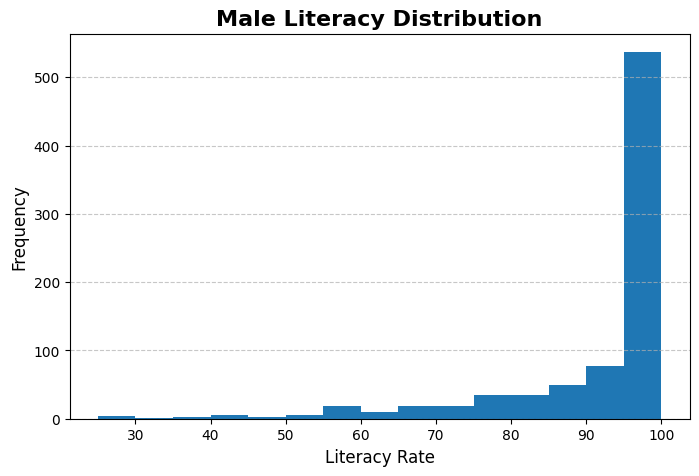

In [ ]:
from matplotlib.lines import lineStyles        # HISTOGRAM
plt.figure(figsize=(8,5))
plt.hist(df_literacy['male_literacy'],bins=15)
plt.title("Male Literacy Distribution",fontsize=16,fontweight='bold')
plt.xlabel("Literacy Rate",fontsize=12)
plt.ylabel("Frequency",fontsize=12)
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

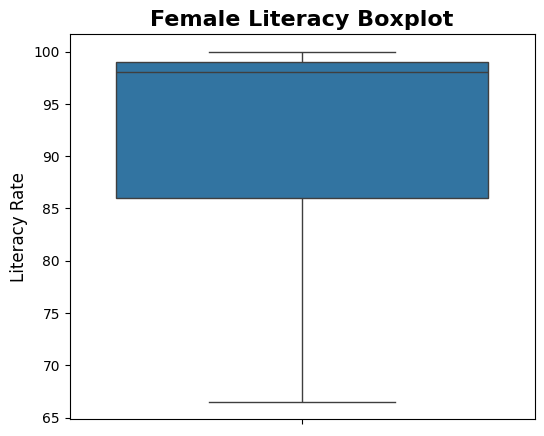

In [ ]:
import seaborn as sns  # BOXPLOT
plt.figure(figsize=(6,5))
sns.boxplot(df_literacy['female_literacy'],showfliers=False)
plt.title("Female Literacy Boxplot",fontsize=16,fontweight='bold')
plt.ylabel("Literacy Rate",fontsize=12)
plt.show()

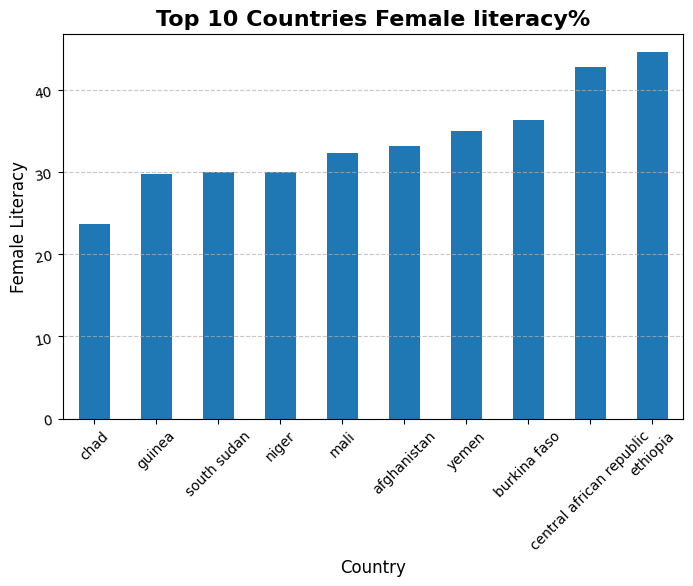

In [ ]:
plt.figure(figsize=(8,5))   # Number Distribution by using Bar Chart
df_literacy.groupby('country')['female_literacy'].mean().sort_values(ascending=True).head(10).plot(kind='bar')
plt.title("Top 10 Countries Female literacy%",fontsize=16,fontweight='bold')
plt.xlabel("Country",fontsize=12)
plt.ylabel("Female Literacy",fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=10)
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

*Univariate Analysis for df_illiteracy*

In [ ]:
df_illiteracy.describe()

,year,illiteracy_rate,literacy_rate,illiteracy_percent
count,1419.000000,1419.000000,1419.000000,1419.000000
mean,2008.534179,20.013274,79.986726,20.013274
std,9.101880,18.144772,18.144772,18.144772
min,1990.000000,0.000000,11.000000,0.000000
25%,2001.000000,5.263798,67.227155,5.263800
50%,2010.000000,13.348106,86.651890,13.348110
75%,2016.000000,32.772847,94.736200,32.772845
max,2023.000000,89.000000,100.000000,89.000000


In [ ]:
import matplotlib.pyplot as plt

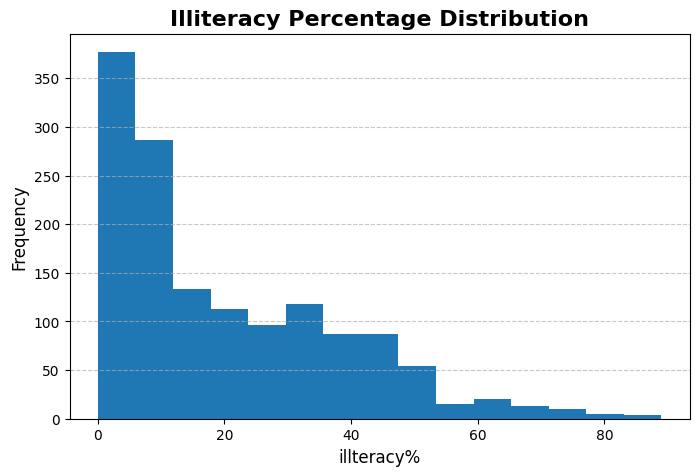

In [ ]:
from matplotlib.lines import lineStyles        # HISTOGRAM
plt.figure(figsize=(8,5))
plt.hist(df_illiteracy['illiteracy_percent'],bins=15)
plt.title("Illiteracy Percentage Distribution",fontsize=16,fontweight='bold')
plt.xlabel("illteracy%",fontsize=12)
plt.ylabel("Frequency",fontsize=12)
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

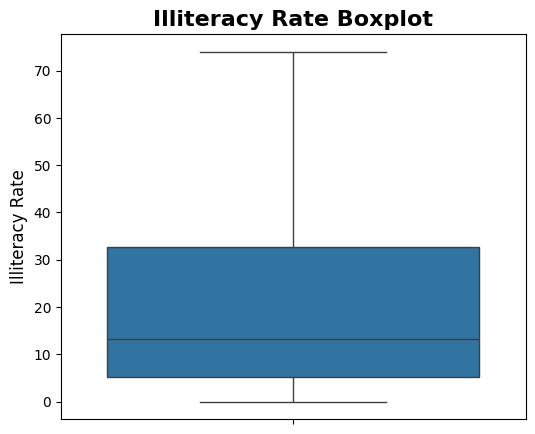

In [ ]:
import seaborn as sns  # BOXPLOT
plt.figure(figsize=(6,5))
sns.boxplot(y=df_illiteracy['illiteracy_rate'],showfliers=False)
plt.title("Illiteracy Rate Boxplot",fontsize=16,fontweight='bold')
plt.ylabel("Illiteracy Rate",fontsize=12)
plt.show()

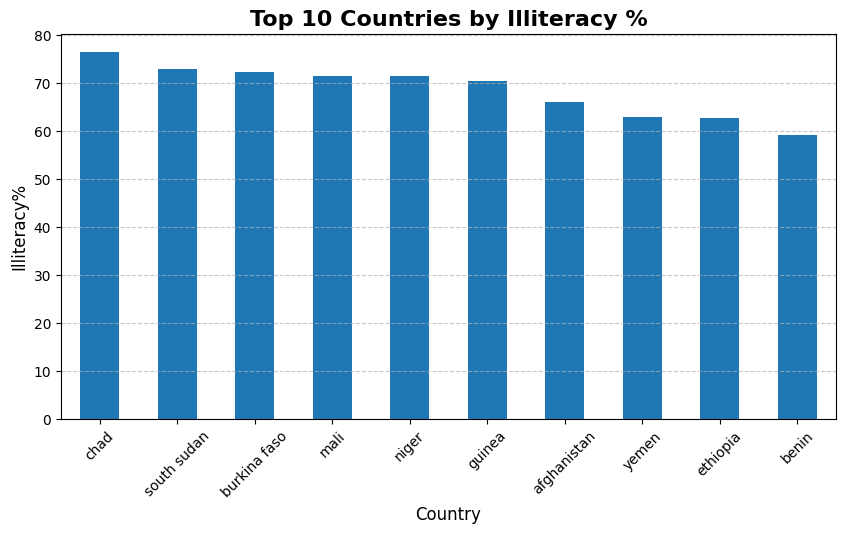

In [ ]:
plt.figure(figsize=(10,5)) #Bar Chart
df_illiteracy.groupby('country')['illiteracy_percent'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Countries by Illiteracy %",fontsize=16,fontweight='bold')
plt.xlabel("Country",fontsize=12)
plt.ylabel("Illiteracy%",fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

*Univariate Analysis for df_gdp_schooling*

---



---



In [ ]:
df_gdp_schooling.describe()

,year,gdp_per_capita,literacy_rate,avg_years_schooling,population_historical,gdp_per_schooling_year,education_index
count,144030.000000,144030.000000,40499.000000,113608.000000,1.440300e+05,1.136080e+05,113608.000000
mean,2006.557821,21396.738440,72.515783,3.830343,3.005034e+07,8.475377e+04,0.278773
std,9.789475,22781.179922,27.971970,3.657782,1.057924e+08,4.027447e+05,0.266214
min,1990.000000,510.822800,0.000000,0.010000,3.424000e+03,9.220857e+01,0.000728
25%,1998.000000,4767.132000,55.000000,0.540000,1.883502e+06,2.581681e+03,0.039301
50%,2007.000000,12415.681000,85.000000,2.780000,5.868459e+06,6.547188e+03,0.202329
75%,2015.000000,32675.305000,95.000000,6.400000,1.808418e+07,2.030843e+04,0.465793
max,2023.000000,174569.520000,100.000000,13.740000,1.438070e+09,7.952135e+06,1.000000


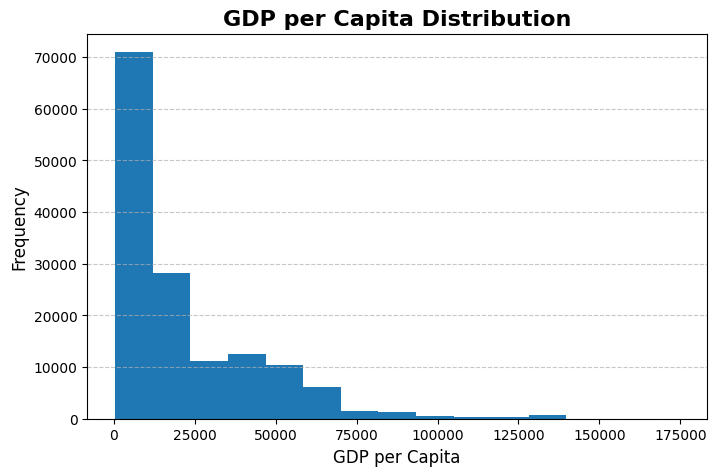

In [ ]:
from matplotlib.lines import lineStyles        # HISTOGRAM
plt.figure(figsize=(8,5))
plt.hist(df_gdp_schooling['gdp_per_capita'],bins=15)
plt.title("GDP per Capita Distribution",fontsize=16,fontweight='bold')
plt.xlabel("GDP per Capita",fontsize=12)
plt.ylabel("Frequency",fontsize=12)
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

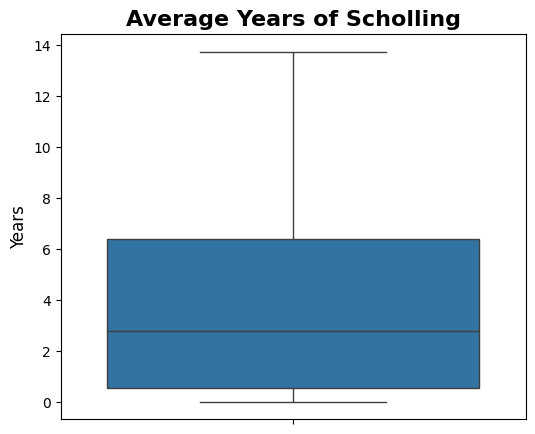

In [ ]:
import seaborn as sns  # BOXPLOT
plt.figure(figsize=(6,5))
sns.boxplot(y=df_gdp_schooling['avg_years_schooling'],showfliers=False)
plt.title("Average Years of Scholling",fontsize=16,fontweight='bold')
plt.ylabel("Years",fontsize=12)
plt.show()

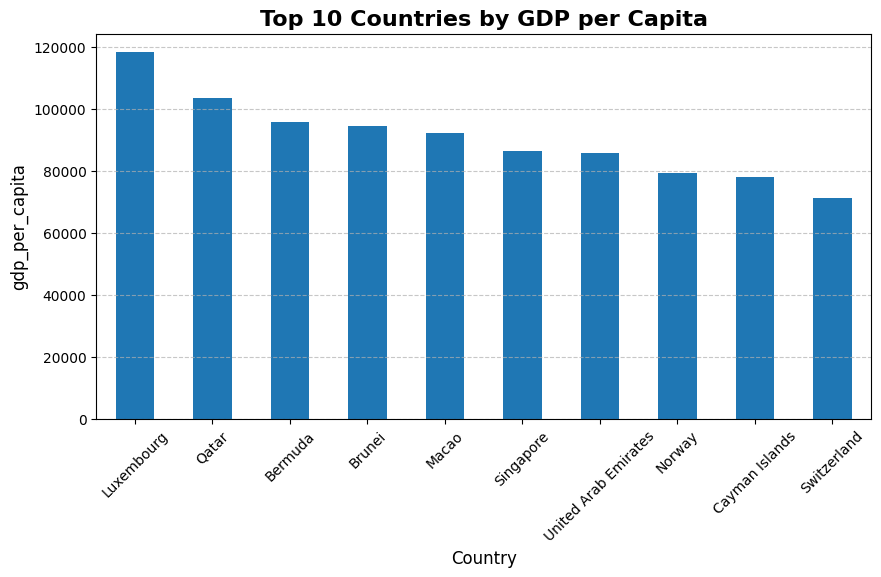

In [ ]:
plt.figure(figsize=(10,5))       #Bar Chart
df_gdp_schooling.groupby('country')['gdp_per_capita'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Countries by GDP per Capita",fontsize=16,fontweight='bold')
plt.xlabel("Country",fontsize=12)
plt.ylabel("gdp_per_capita",fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

Bivariate Analysis for df_literacy

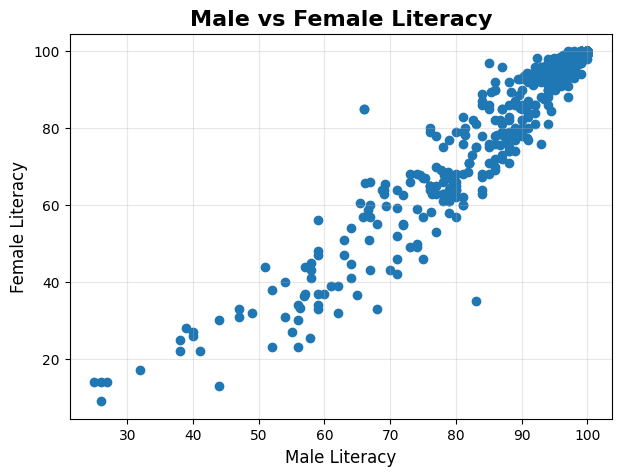

In [ ]:
import matplotlib.pyplot as plt   #Scatter plot with strong positive correlation
plt.figure(figsize=(7,5))
plt.scatter(df_literacy['male_literacy'],df_literacy['female_literacy'])
plt.title("Male vs Female Literacy",fontsize=16,fontweight='bold')
plt.xlabel("Male Literacy",fontsize=12)
plt.ylabel("Female Literacy",fontsize=12)
plt.grid(alpha=0.3)
plt.show()

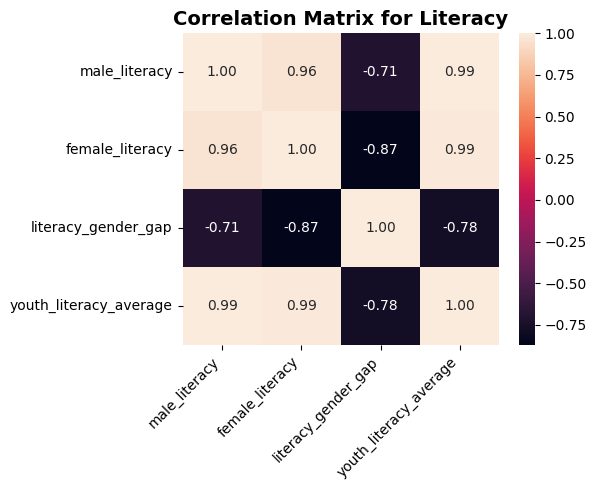

In [ ]:
import seaborn as sns    #Correlation Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    df_literacy[['male_literacy', 'female_literacy','literacy_gender_gap','youth_literacy_average']].corr(),annot=True,fmt=".2f"
)
plt.title("Correlation Matrix for Literacy",fontsize=14,fontweight='bold')
plt.xticks(rotation=45,ha='right',fontsize=10)
plt.tight_layout()
plt.show()

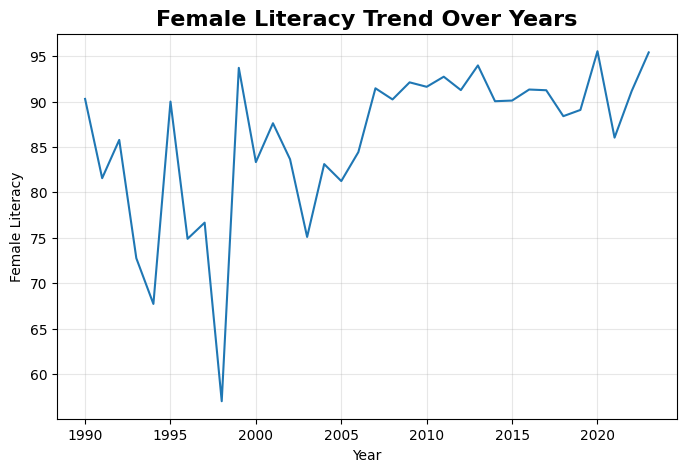

In [ ]:
plt.figure(figsize=(8,5)) #Line Trend
df_literacy.groupby('year')['female_literacy'].mean().plot()
plt.title("Female Literacy Trend Over Years",fontsize=16,fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Female Literacy")
plt.grid(alpha=0.3)
plt.show()

*Bivariate for df_illiteracy*

In [ ]:
df_illiteracy.columns

Index(['country', 'country_code', 'year', 'illiteracy_rate', 'literacy_rate',
       'illiteracy_percent'],
      dtype='object')

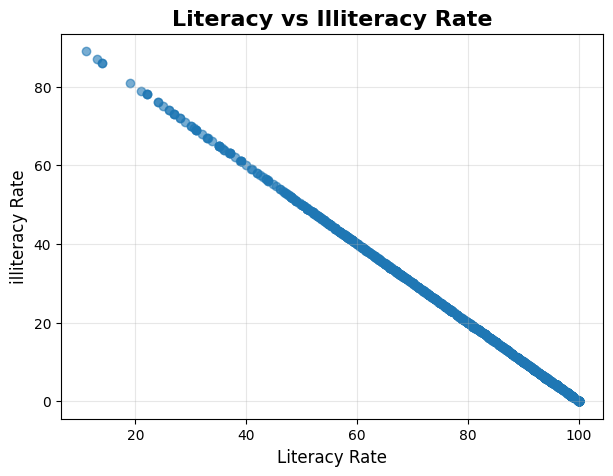

In [ ]:
import matplotlib.pyplot as plt   #Scatter plot with strong positive correlation
plt.figure(figsize=(7,5))
plt.scatter(df_illiteracy['literacy_rate'],df_illiteracy['illiteracy_rate'],alpha=0.6)
plt.title("Literacy vs Illiteracy Rate",fontsize=16,fontweight='bold')
plt.xlabel("Literacy Rate",fontsize=12)
plt.ylabel("illiteracy Rate",fontsize=12)
plt.grid(alpha=0.3)
plt.show()

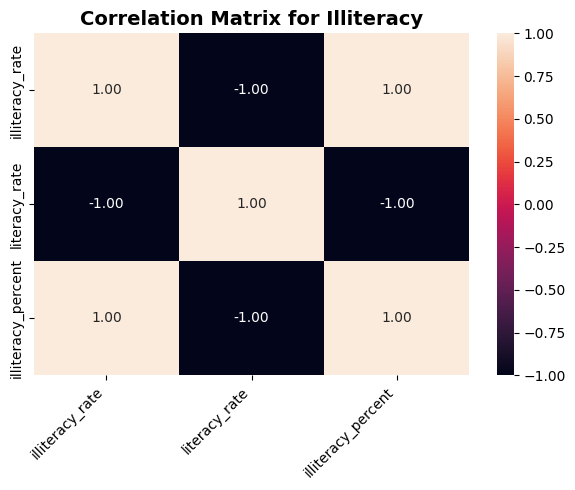

In [ ]:
import seaborn as sns    #Correlation Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    df_illiteracy[['illiteracy_rate','literacy_rate','illiteracy_percent']].corr(),annot=True,fmt=".2f"
)
plt.title("Correlation Matrix for Illiteracy",fontsize=14,fontweight='bold')
plt.xticks(rotation=45,ha='right',fontsize=10)
plt.tight_layout()
plt.show()

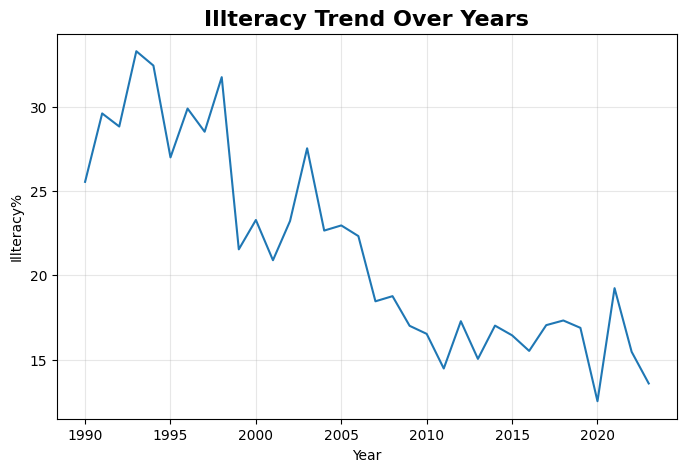

In [ ]:
plt.figure(figsize=(8,5)) #Line Trend
df_illiteracy.groupby('year')['illiteracy_percent'].mean().plot()
plt.title("Illteracy Trend Over Years",fontsize=16,fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Illteracy%")
plt.grid(alpha=0.3)
plt.show()

*Bivariate for df_gdp_schooling*

In [ ]:
df_gdp_schooling.columns

Index(['country', 'country_code', 'year', 'gdp_per_capita', 'continent',
       'literacy_rate', 'avg_years_schooling', 'population_historical',
       'gdp_per_schooling_year', 'education_index'],
      dtype='object')

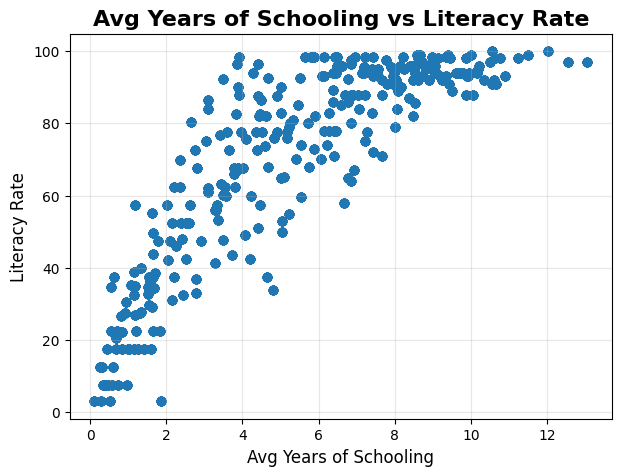

In [ ]:
import matplotlib.pyplot as plt   #Scatter plot with strong positive correlation
plt.figure(figsize=(7,5))
plt.scatter(df_gdp_schooling['avg_years_schooling'],df_gdp_schooling['literacy_rate'],alpha=0.4)
plt.title("Avg Years of Schooling vs Literacy Rate",fontsize=16,fontweight='bold')
plt.xlabel("Avg Years of Schooling",fontsize=12)
plt.ylabel("Literacy Rate",fontsize=12)
plt.grid(alpha=0.3)
plt.show()

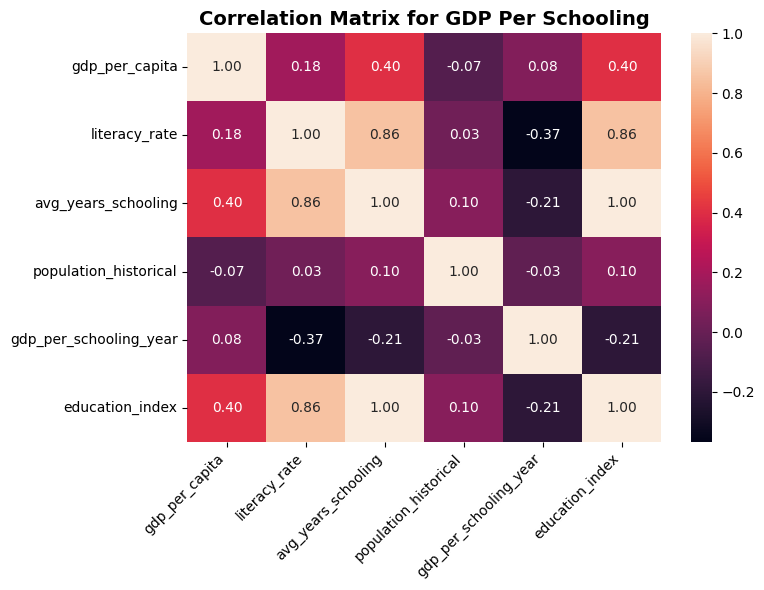

In [ ]:
import seaborn as sns    #Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    df_gdp_schooling[['gdp_per_capita','literacy_rate','avg_years_schooling','population_historical',
       'gdp_per_schooling_year','education_index']].corr(),annot=True,fmt=".2f"

)
plt.title("Correlation Matrix for GDP Per Schooling",fontsize=14,fontweight='bold')
plt.xticks(rotation=45,ha='right',fontsize=10)
plt.tight_layout()
plt.show()

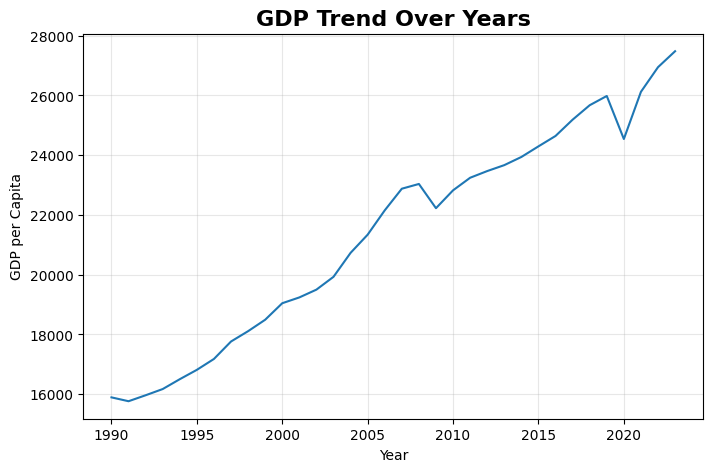

In [ ]:
plt.figure(figsize=(8,5)) #Line Trend
df_gdp_schooling.groupby('year')['gdp_per_capita'].mean().plot()
plt.title("GDP Trend Over Years",fontsize=16,fontweight='bold')
plt.xlabel("Year")
plt.ylabel("GDP per Capita")
plt.grid(alpha=0.3)
plt.show()

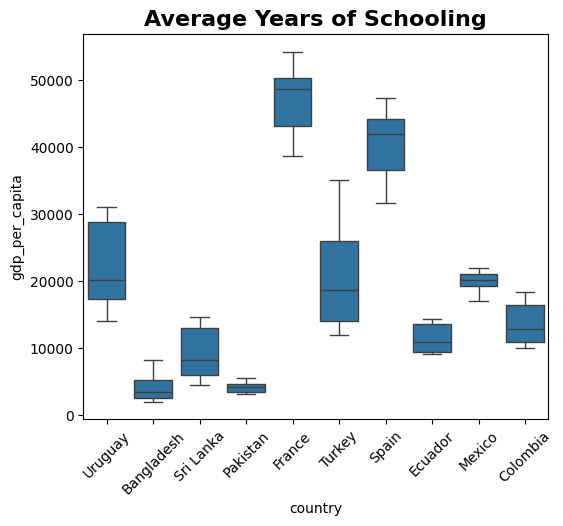

In [ ]:
top_countries=df_gdp_schooling['country'].value_counts().head(10).index  # Boxplot just made for gdp only
plt.figure(figsize=(6,5))
sns.boxplot(
    x='country',
    y='gdp_per_capita',
    data=df_gdp_schooling[df_gdp_schooling['country'].isin(top_countries)]
)
plt.title("Average Years of Schooling",fontsize=16,fontweight='bold')
plt.xticks(rotation=45)
plt.show()

In [ ]:
!pip install mysql-connector-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 44.9 MB/s eta 0:00:00


In [ ]:
import mysql.connector
connection=mysql.connector.connect(
    host="gateway01.ap-southeast-1.prod.aws.tidbcloud.com",
    user="41fEDb4Zwh2ZfU2.root",
    password="N8jnsUwXMkbYKfwU",
    database="global_trend_project",
    port=4000
)
cursor = connection.cursor()

In [ ]:
cursor.execute("Show Tables")
for table in cursor:
  print(table)

('gdp_per_schooling_rates',)
('illiteracy_rates',)
('literacy_rates',)


In [ ]:
df_literacy.columns

Index(['country', 'country_code', 'year', 'Total_literacy_population',
       'male_literacy', 'female_literacy', 'continent', 'literacy_gender_gap',
       'youth_literacy_average', 'gender_equality_index'],
      dtype='object')

In [ ]:

data=[tuple(row) for row in df_literacy[['country', 'country_code', 'year',
                                         'Total_literacy_population','male_literacy','female_literacy','continent','literacy_gender_gap',
                                         'youth_literacy_average', 'gender_equality_index']].to_numpy()]

In [ ]:
cursor.executemany("""
  INSERT INTO literacy_rates
  (country,country_code,year,Total_literacy_population,male_literacy,
  female_literacy,continent,literacy_gender_gap,youth_literacy_average,gender_equality_index)
  VALUES(%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
  ON DUPLICATE KEY UPDATE
  Total_literacy_population=VALUES(Total_literacy_population),
  male_literacy=VALUES(male_literacy),
  female_literacy=VALUES(female_literacy),
  continent=VALUES(continent),
  literacy_gender_gap=VALUES(literacy_gender_gap),
  youth_literacy_average=VALUES(youth_literacy_average),
  gender_equality_index=VALUES(gender_equality_index)
  """,data)
connection.commit()

In [ ]:
df_illiteracy.columns

Index(['country', 'country_code', 'year', 'illiteracy_rate', 'literacy_rate',
       'illiteracy_percent'],
      dtype='object')

In [ ]:
data=[tuple(row) for row in df_illiteracy[['country', 'country_code', 'year', 'illiteracy_rate',
                                           'literacy_rate','illiteracy_percent']].to_numpy()]

In [ ]:
cursor.executemany
("""INSERT INTO illiteracy_rates
(country, country_code, year, illiteracy_rate, literacy_rate, illiteracy_percent)
VALUES (%s, %s, %s, %s, %s, %s)
ON DUPLICATE KEY UPDATE
illiteracy_rate=VALUES(illiteracy_rate),
literacy_rate=VALUES(literacy_rate),
illiteracy_percent=VALUES(illiteracy_percent)
""", data)
connection.commit()


In [ ]:
df_gdp_schooling.columns

Index(['country', 'country_code', 'year', 'gdp_per_capita', 'continent',
       'literacy_rate', 'avg_years_schooling', 'population_historical',
       'gdp_per_schooling_year', 'education_index'],
      dtype='object')

In [ ]:
data=[tuple(row) for row in df_gdp_schooling[['country','country_code','year','gdp_per_capita','continent',
                                              'literacy_rate','avg_years_schooling','population_historical',
                                              'gdp_per_schooling_year','education_index']].to_numpy()]

In [ ]:
cursor.executemany("""
INSERT INTO gdp_per_schooling_rates
(country, country_code, year, gdp_per_capita, continent, literacy_rate, avg_years_schooling, population_historical,
 gdp_per_schooling_year, education_index)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
ON DUPLICATE KEY UPDATE
gdp_per_capita=VALUES(gdp_per_capita),
continent=VALUES(continent),
literacy_rate=VALUES(literacy_rate),
avg_years_schooling=VALUES(avg_years_schooling),
population_historical=VALUES(population_historical),
gdp_per_schooling_year=VALUES(gdp_per_schooling_year),
education_index=VALUES(education_index)
""", data)
connection.commit()